In [4]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Optimized MPC-DNN Federated Intrusion Detection on TON_IOT

This version improves the TON_IOT experiment without using test-set information:

- constrained Dirichlet non-IID partitioning gives every client a minimum amount of
  every class while preserving heterogeneous class proportions;
- the main benchmark uses clean clients, while label-noise clients remain available
  as a separate robustness experiment;
- a wider regularized DNN improves representation capacity;
- the best global round is selected using validation macro-F1, never test performance;
- the test set is evaluated once after model selection.

The default task remains TON_IOT 10-class classification. A score above 90% is a target,
not a guaranteed outcome; report the observed result honestly.

In [5]:
from pathlib import Path
import json
import logging
import os
import random
import sys
from collections import Counter, defaultdict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils import class_weight, resample

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)

## Experiment Configuration

For the paper experiment, keep `FAST_RUN = False`. The fast mode is only a pipeline
smoke test and must not be reported as the final result.

In [6]:
local_data_path = Path("./train_test_network.csv")
kaggle_data_path = Path(
    "/kaggle/input/datasets/shiyunli123/ton-iot/train_test_network.csv"
)
DATA_PATH = local_data_path if local_data_path.exists() else kaggle_data_path

TARGET_MODE = "multiclass"  # "multiclass" -> type; "binary" -> label
EXPERIMENT_MODE = "clean"   # "clean" for the main benchmark; "robust" for attack testing
FAST_RUN = False

NUM_CLIENTS = 5
DIRICHLET_ALPHA = 0.7
MIN_SAMPLES_PER_CLASS_PER_CLIENT = 500
SHARE_PCT = 0.05
SHARE_FRACTION = 0.50

CORRUPT_CLIENTS = [0, 3] if EXPERIMENT_MODE == "robust" else []
CORRUPTION_RATE = 1.0

NUM_ROUNDS = 15 if not FAST_RUN else 2
EPOCHS = 4 if not FAST_RUN else 1
BATCH_SIZE = 512
LEARNING_RATE = 5e-4
NOISE_SCALE = 1e-4
VALIDATION_THRESHOLD = 0.25 if TARGET_MODE == "multiclass" else 0.60

RESAMPLE_MULTICLASS_TRAIN = TARGET_MODE == "multiclass"
SAMPLES_PER_CLASS = 15_000 if not FAST_RUN else 1_000

RUN_NAME = f"ton_iot_{TARGET_MODE}_{EXPERIMENT_MODE}_optimized"
OUTPUT_DIR = Path(RUN_NAME)
CLIENT_MODEL_DIR = OUTPUT_DIR / "client_models"
GLOBAL_MODEL_DIR = OUTPUT_DIR / "global_models"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in (OUTPUT_DIR, CLIENT_MODEL_DIR, GLOBAL_MODEL_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print({
    "target_mode": TARGET_MODE,
    "experiment_mode": EXPERIMENT_MODE,
    "rounds": NUM_ROUNDS,
    "epochs": EPOCHS,
    "clients": NUM_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "corrupt_clients": CORRUPT_CLIENTS,
    "fast_run": FAST_RUN,
})

{'target_mode': 'multiclass', 'experiment_mode': 'clean', 'rounds': 15, 'epochs': 4, 'clients': 5, 'dirichlet_alpha': 0.7, 'corrupt_clients': [], 'fast_run': False}


## Load and Inspect TON_IOT

In [7]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Dataset shape:", df.shape)
display(df.head())
display(df[["label", "type"]].value_counts().rename("count").reset_index())

Dataset shape: (211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor


,label,type,count
0,0,normal,50000
1,1,backdoor,20000
2,1,ddos,20000
3,1,dos,20000
4,1,injection,20000
5,1,password,20000
6,1,ransomware,20000
7,1,scanning,20000
8,1,xss,20000
9,1,mitm,1043


## Leakage-Safe Split and Preprocessing

High-cardinality identifiers and free-text fields are removed following the reference
TON_IOT notebook. The preprocessor is fitted on the training split only.

In [8]:
target_col = "type" if TARGET_MODE == "multiclass" else "label"

drop_columns = [
    "label",
    "type",
    "src_ip",
    "dst_ip",
    "dns_query",
    "ssl_subject",
    "ssl_issuer",
    "http_uri",
    "http_user_agent",
]

X_raw = df.drop(columns=drop_columns)
y_raw = df[target_col].astype(str) if TARGET_MODE == "multiclass" else df[target_col].astype(int)

X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.30,
    random_state=SEED,
    stratify=y_raw,
)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw,
    y_temp_raw,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_raw,
)

if FAST_RUN:
    def stratified_subset(X, y, max_rows):
        if len(y) <= max_rows:
            return X, y
        X_keep, _, y_keep, _ = train_test_split(
            X, y, train_size=max_rows, random_state=SEED, stratify=y
        )
        return X_keep, y_keep

    X_train_raw, y_train_raw = stratified_subset(X_train_raw, y_train_raw, 20_000)
    X_val_raw, y_val_raw = stratified_subset(X_val_raw, y_val_raw, 5_000)
    X_test_raw, y_test_raw = stratified_subset(X_test_raw, y_test_raw, 5_000)

print("Raw splits:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

Raw splits: (147730, 35) (31656, 35) (31657, 35)


In [9]:
numeric_features = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", one_hot),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

X_train = np.asarray(preprocessor.fit_transform(X_train_raw), dtype=np.float32)
X_val = np.asarray(preprocessor.transform(X_val_raw), dtype=np.float32)
X_test = np.asarray(preprocessor.transform(X_test_raw), dtype=np.float32)

if TARGET_MODE == "multiclass":
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw).astype(np.int64)
    y_val = label_encoder.transform(y_val_raw).astype(np.int64)
    y_test = label_encoder.transform(y_test_raw).astype(np.int64)
else:
    label_encoder = LabelEncoder()
    label_encoder.fit(["normal", "attack"])
    label_encoder.classes_ = np.asarray(["normal", "attack"])
    y_train = y_train_raw.to_numpy(dtype=np.int64)
    y_val = y_val_raw.to_numpy(dtype=np.int64)
    y_test = y_test_raw.to_numpy(dtype=np.int64)

feature_names = preprocessor.get_feature_names_out()
print("Encoded shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", label_encoder.classes_.tolist())

Encoded shapes: (147730, 113) (31656, 113) (31657, 113)
Classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


## Training-Only Class Balancing

Only the multiclass training partition is resampled. Validation and test distributions
remain untouched and therefore represent the original TON_IOT data.

In [10]:
def balance_training_classes(X, y, samples_per_class, random_state=SEED):
    rng_frames = []
    frame = pd.DataFrame(X)
    frame["_target"] = y

    for cls in np.unique(y):
        class_rows = frame[frame["_target"] == cls]
        sampled = resample(
            class_rows,
            replace=len(class_rows) < samples_per_class,
            n_samples=samples_per_class,
            random_state=random_state + int(cls),
        )
        rng_frames.append(sampled)

    balanced = pd.concat(rng_frames, ignore_index=True)
    balanced = balanced.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return (
        balanced.drop(columns="_target").to_numpy(dtype=np.float32),
        balanced["_target"].to_numpy(dtype=np.int64),
    )


print("Before balancing:", Counter(y_train))
if RESAMPLE_MULTICLASS_TRAIN:
    X_train, y_train = balance_training_classes(
        X_train, y_train, samples_per_class=SAMPLES_PER_CLASS
    )
print("After balancing:", Counter(y_train))

Before balancing: Counter({5: 35000, 1: 14000, 8: 14000, 3: 14000, 6: 14000, 7: 14000, 9: 14000, 0: 14000, 2: 14000, 4: 730})
After balancing: Counter({3: 15000, 1: 15000, 8: 15000, 9: 15000, 6: 15000, 4: 15000, 2: 15000, 5: 15000, 7: 15000, 0: 15000})


## Constrained Dirichlet Non-IID Partition

For every class, each client first receives a minimum number of examples. The remaining
examples are distributed according to a Dirichlet distribution. This retains measurable
non-IID heterogeneity without making a class depend on only one client.

In [11]:
def distribution_distance(p, q):
    return float(np.sum(np.abs(p - q)))


def _dirichlet_counts(total, num_clients, alpha, rng):
    proportions = rng.dirichlet(np.full(num_clients, alpha))
    raw = proportions * total
    counts = np.floor(raw).astype(int)
    remainder = total - counts.sum()
    if remainder:
        order = np.argsort(raw - counts)[::-1]
        counts[order[:remainder]] += 1
    return counts


def partition_dirichlet_with_coverage(
    X,
    y,
    num_clients,
    alpha,
    min_samples_per_class,
    share_pct,
    share_fraction,
    random_state=SEED,
):
    rng = np.random.default_rng(random_state)
    labels = np.unique(y)

    share_indices = []
    local_by_label = {}
    for label in labels:
        idx = np.flatnonzero(y == label)
        rng.shuffle(idx)
        n_share = int(len(idx) * share_pct) if share_pct > 0 else 0
        share_indices.extend(idx[:n_share])
        local_by_label[int(label)] = idx[n_share:]

    share_indices = np.asarray(share_indices, dtype=int)
    X_share, y_share = X[share_indices], y[share_indices]
    assignments = {cid: [] for cid in range(num_clients)}

    for label, idx in local_by_label.items():
        required = min_samples_per_class * num_clients
        if required > len(idx):
            raise ValueError(
                f"Class {label} has {len(idx)} local samples, fewer than the "
                f"{required} required by the coverage constraint."
            )

        cursor = 0
        for cid in range(num_clients):
            stop = cursor + min_samples_per_class
            assignments[cid].extend(idx[cursor:stop].tolist())
            cursor = stop

        remaining = idx[cursor:]
        counts = _dirichlet_counts(len(remaining), num_clients, alpha, rng)
        cursor = 0
        for cid, count in enumerate(counts):
            stop = cursor + count
            assignments[cid].extend(remaining[cursor:stop].tolist())
            cursor = stop

    n_classes = int(labels.max()) + 1
    global_hist = np.bincount(y, minlength=n_classes) / len(y)
    client_data = {}
    stats = {"label_hist": {}, "distance": {}, "global_hist": global_hist}

    for cid in range(num_clients):
        idx = np.asarray(assignments[cid], dtype=int)
        X_client, y_client = X[idx], y[idx]

        if len(X_share) and share_fraction > 0:
            n_client_share = min(
                len(X_share), max(1, int(len(X_share) * share_fraction))
            )
            selected = rng.choice(len(X_share), size=n_client_share, replace=False)
            X_client = np.concatenate([X_client, X_share[selected]], axis=0)
            y_client = np.concatenate([y_client, y_share[selected]], axis=0)

        order = rng.permutation(len(y_client))
        X_client, y_client = X_client[order], y_client[order]
        client_data[cid] = (X_client, y_client)

        hist = np.bincount(y_client, minlength=n_classes) / len(y_client)
        stats["label_hist"][cid] = hist
        stats["distance"][cid] = distribution_distance(hist, global_hist)

    return client_data, stats


client_data, partition_stats = partition_dirichlet_with_coverage(
    X_train,
    y_train,
    num_clients=NUM_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    min_samples_per_class=MIN_SAMPLES_PER_CLASS_PER_CLIENT,
    share_pct=SHARE_PCT,
    share_fraction=SHARE_FRACTION,
)

for cid, (_, labels) in client_data.items():
    counts = dict(sorted(Counter(labels).items()))
    print(
        f"Client {cid}: n={len(labels):,}, "
        f"distance={partition_stats['distance'][cid]:.4f}, counts={counts}"
    )
    missing = set(range(len(label_encoder.classes_))) - set(counts)
    if missing:
        raise RuntimeError(f"Client {cid} is missing classes: {sorted(missing)}")

Client 0: n=43,268, distance=0.5628, counts={0: 5570, 1: 1790, 2: 902, 3: 1257, 4: 1183, 5: 8636, 6: 4819, 7: 5410, 8: 8788, 9: 4913}
Client 1: n=22,404, distance=0.4804, counts={0: 3152, 1: 910, 2: 4991, 3: 873, 4: 1150, 5: 3048, 6: 3103, 7: 989, 8: 1899, 9: 2289}
Client 2: n=37,170, distance=0.5713, counts={0: 2206, 1: 5468, 2: 1472, 3: 4426, 4: 9297, 5: 1888, 6: 3485, 7: 1564, 8: 1070, 9: 6294}
Client 3: n=24,075, distance=0.5992, counts={0: 1089, 1: 3886, 2: 6408, 3: 3792, 4: 1390, 5: 913, 6: 2757, 7: 1272, 8: 1368, 9: 1200}
Client 4: n=34,333, distance=0.4076, counts={0: 4092, 1: 4081, 2: 2404, 3: 5689, 4: 3084, 5: 1682, 6: 1971, 7: 6868, 8: 3018, 9: 1444}


## Optional Label-Noise Clients

The main dataset comparison should use `EXPERIMENT_MODE = "clean"`. Use `"robust"` as
a separate stress test. `CORRUPTION_RATE` controls the fraction of labels shuffled on
each malicious client.

In [12]:
clean_client_data = {
    cid: (X_client.copy(), y_client.copy())
    for cid, (X_client, y_client) in client_data.items()
}

rng = np.random.default_rng(SEED)
for cid in CORRUPT_CLIENTS:
    if cid not in client_data:
        continue
    X_client, y_client = client_data[cid]
    noisy_labels = y_client.copy()
    n_corrupt = int(len(noisy_labels) * CORRUPTION_RATE)
    corrupt_idx = rng.choice(len(noisy_labels), size=n_corrupt, replace=False)
    shuffled = noisy_labels[corrupt_idx].copy()
    rng.shuffle(shuffled)
    noisy_labels[corrupt_idx] = shuffled
    client_data[cid] = (X_client, noisy_labels)

print("Corrupted clients:", CORRUPT_CLIENTS)
print("Corruption rate:", CORRUPTION_RATE if CORRUPT_CLIENTS else 0.0)

Corrupted clients: []
Corruption rate: 0.0


In [13]:
classes = np.arange(len(label_encoder.classes_))
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
num_classes = len(classes)
input_dim = X_train.shape[1]

print("Input dimension:", input_dim)
print("Number of classes:", num_classes)
print("Class weights:", class_weights)

Input dimension: 113
Number of classes: 10
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}


## TensorFlow Model

TensorFlow is required for the cells below. Install a TensorFlow build compatible with
your Python/CUDA environment before running the full experiment.

In [14]:
try:
    import tensorflow as tf
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.layers import (
        Activation,
        BatchNormalization,
        Dense,
        Dropout,
        Input,
    )
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is required for federated training. Install tensorflow in this "
        "notebook kernel, then restart the kernel and run all cells."
    ) from exc

tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
def create_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.20),
        Dense(128, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.15),
        Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
        Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


global_model = create_model(input_dim, num_classes)
global_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               29184     
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 256)               0         
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                        

## Corrected Validation-Aware Secure Aggregation

Aggregation weights and mask cancellation are calculated only over clients that pass
behavioral validation. This corrects the original notebook's scaling and mask mismatch
when one or more clients are rejected.

In [16]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] %(levelname)s: %(message)s",
    handlers=[
        logging.FileHandler(OUTPUT_DIR / "fl_training.log"),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)
logger = logging.getLogger("ton_iot_federated")


def make_shared_validation_set(X, y, fraction=0.50, seed=SEED):
    _, X_shared, _, y_shared = train_test_split(
        X, y, test_size=fraction, random_state=seed, stratify=y
    )
    return X_shared, y_shared


def validate_client(model, X_shared, y_shared, threshold):
    _, accuracy = model.evaluate(X_shared, y_shared, verbose=0)
    return bool(accuracy >= threshold), float(accuracy)


def generate_noise_masks(model, client_ids, seed):
    rng = np.random.default_rng(seed)
    return {
        cid: [
            rng.normal(0.0, NOISE_SCALE, size=weight.shape).astype(weight.dtype)
            for weight in model.get_weights()
        ]
        for cid in client_ids
    }


def secure_weighted_aggregation(local_results, noise_masks):
    if not local_results:
        raise RuntimeError("All clients were rejected; global model was not updated.")

    total_samples = sum(result["n_samples"] for result in local_results)
    masked_sum = None
    effective_noise = None

    for result in local_results:
        cid = result["client_id"]
        factor = result["n_samples"] / total_samples
        contribution = [
            factor * weight + noise_masks[cid][layer_idx]
            for layer_idx, weight in enumerate(result["weights"])
        ]
        if masked_sum is None:
            masked_sum = [value.copy() for value in contribution]
            effective_noise = [value.copy() for value in noise_masks[cid]]
        else:
            masked_sum = [
                aggregate + value for aggregate, value in zip(masked_sum, contribution)
            ]
            effective_noise = [
                aggregate + value
                for aggregate, value in zip(effective_noise, noise_masks[cid])
            ]

    return [
        aggregate - noise
        for aggregate, noise in zip(masked_sum, effective_noise)
    ]


def train_one_client(global_model, cid, X_client, y_client, round_number):
    local_model = tf.keras.models.clone_model(global_model)
    local_model.set_weights(global_model.get_weights())
    local_model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True, min_delta=1e-4
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5, verbose=0
        ),
    ]
    history = local_model.fit(
        X_client,
        y_client,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks,
        class_weight=class_weights,
    )
    return local_model, history.history

In [17]:
def evaluate_model(model, X_eval, y_eval):
    probabilities = model.predict(X_eval, batch_size=BATCH_SIZE, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    return {
        "accuracy": accuracy_score(y_eval, predictions),
        "precision_macro": precision_score(
            y_eval, predictions, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_eval, predictions, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_eval, predictions, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_eval, predictions, average="weighted", zero_division=0
        ),
    }, predictions


def federated_training(global_model):
    round_rows = []
    client_rows = []
    client_ids = sorted(client_data)
    best_val_f1 = -np.inf
    best_round = None
    best_model_path = GLOBAL_MODEL_DIR / "best_global_model.keras"

    for round_number in range(1, NUM_ROUNDS + 1):
        logger.info("Federated round %d/%d", round_number, NUM_ROUNDS)
        X_shared, y_shared = make_shared_validation_set(
            X_val, y_val, fraction=0.50, seed=SEED + round_number
        )
        noise_masks = generate_noise_masks(
            global_model, client_ids, seed=SEED + round_number
        )
        local_results = []

        for cid in client_ids:
            X_client, y_client = client_data[cid]
            logger.info("Training client %d with %d samples", cid, len(y_client))
            local_model, local_history = train_one_client(
                global_model, cid, X_client, y_client, round_number
            )
            passed, validation_accuracy = validate_client(
                local_model, X_shared, y_shared, VALIDATION_THRESHOLD
            )
            client_rows.append({
                "round": round_number,
                "client_id": cid,
                "is_corrupt": cid in CORRUPT_CLIENTS,
                "n_samples": len(y_client),
                "validation_accuracy": validation_accuracy,
                "passed": passed,
                "final_train_accuracy": local_history["accuracy"][-1],
                "final_train_loss": local_history["loss"][-1],
            })

            if passed:
                local_results.append({
                    "client_id": cid,
                    "n_samples": len(y_client),
                    "weights": local_model.get_weights(),
                })
                logger.info(
                    "Client %d accepted (validation accuracy %.4f)",
                    cid, validation_accuracy
                )
            else:
                logger.warning(
                    "Client %d rejected (validation accuracy %.4f)",
                    cid, validation_accuracy
                )
            del local_model
            tf.keras.backend.clear_session()

        global_model.set_weights(
            secure_weighted_aggregation(local_results, noise_masks)
        )
        val_metrics, _ = evaluate_model(global_model, X_val, y_val)
        row = {
            **val_metrics,
            "round": round_number,
            "accepted_clients": len(local_results),
            "rejected_clients": NUM_CLIENTS - len(local_results),
        }
        round_rows.append(row)
        logger.info("Validation metrics: %s", row)

        global_model.save(
            GLOBAL_MODEL_DIR / f"global_model_round_{round_number:02d}.keras"
        )
        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_round = round_number
            global_model.save(best_model_path)
            logger.info(
                "New best model at round %d (validation macro-F1 %.4f)",
                best_round, best_val_f1
            )

        pd.DataFrame(round_rows).to_csv(
            OUTPUT_DIR / "validation_round_metrics.csv", index=False
        )
        pd.DataFrame(client_rows).to_csv(
            OUTPUT_DIR / "client_validation_metrics.csv", index=False
        )

    best_model = load_model(best_model_path)
    print(f"Best round: {best_round}; validation macro-F1: {best_val_f1:.4f}")
    return (
        best_model,
        pd.DataFrame(round_rows),
        pd.DataFrame(client_rows),
        best_round,
    )


trained_model, round_metrics, client_metrics, best_round = federated_training(
    global_model
)
display(round_metrics)
display(client_metrics)

[2026-06-11 16:44:40,119] INFO: Federated round 1/15
[2026-06-11 16:44:40,187] INFO: Training client 0 with 43268 samples
Epoch 1/4
85/85 [==============================] - 4s 22ms/step - loss: 1.0762 - accuracy: 0.7051 - val_loss: 1.4562 - val_accuracy: 0.7431 - lr: 5.0000e-04
Epoch 2/4
85/85 [==============================] - 2s 18ms/step - loss: 0.5865 - accuracy: 0.8235 - val_loss: 0.9783 - val_accuracy: 0.7610 - lr: 5.0000e-04
Epoch 3/4
85/85 [==============================] - 2s 19ms/step - loss: 0.5120 - accuracy: 0.8435 - val_loss: 0.6915 - val_accuracy: 0.7923 - lr: 5.0000e-04
Epoch 4/4
85/85 [==============================] - 2s 18ms/step - loss: 0.4731 - accuracy: 0.8513 - val_loss: 0.5865 - val_accuracy: 0.8034 - lr: 5.0000e-04
[2026-06-11 16:44:50,795] INFO: Client 0 accepted (validation accuracy 0.8026)
[2026-06-11 16:44:50,815] INFO: Training client 1 with 22404 samples
Epoch 1/4
44/44 [==============================] - 2s 29ms/step - loss: 1.3116 - accuracy: 0.6468 - va

[2026-06-11 16:46:07,833] INFO: Validation metrics: {'accuracy': 0.8238564569118019, 'precision_macro': 0.7584021075123288, 'recall_macro': 0.8238317948717949, 'f1_macro': 0.7599924425505471, 'f1_weighted': 0.8295765608470719, 'round': 2, 'accepted_clients': 5, 'rejected_clients': 0}
[2026-06-11 16:46:07,948] INFO: New best model at round 2 (validation macro-F1 0.7600)
[2026-06-11 16:46:07,957] INFO: Federated round 3/15
[2026-06-11 16:46:08,023] INFO: Training client 0 with 43268 samples
Epoch 1/4
85/85 [==============================] - 3s 21ms/step - loss: 0.4395 - accuracy: 0.8579 - val_loss: 0.5387 - val_accuracy: 0.8042 - lr: 5.0000e-04
Epoch 2/4
85/85 [==============================] - 1s 17ms/step - loss: 0.4105 - accuracy: 0.8651 - val_loss: 0.5061 - val_accuracy: 0.8022 - lr: 5.0000e-04
Epoch 3/4
85/85 [==============================] - 2s 18ms/step - loss: 0.3906 - accuracy: 0.8724 - val_loss: 0.4766 - val_accuracy: 0.8059 - lr: 5.0000e-04
Epoch 4/4
85/85 [==================

Epoch 3/4
68/68 [==============================] - 1s 20ms/step - loss: 0.4076 - accuracy: 0.8755 - val_loss: 0.5280 - val_accuracy: 0.8057 - lr: 5.0000e-04
Epoch 4/4
68/68 [==============================] - 1s 19ms/step - loss: 0.4024 - accuracy: 0.8751 - val_loss: 0.5126 - val_accuracy: 0.8078 - lr: 2.5000e-04
[2026-06-11 16:47:35,626] INFO: Client 4 accepted (validation accuracy 0.8059)
[2026-06-11 16:47:36,007] INFO: Validation metrics: {'accuracy': 0.8357657316148598, 'precision_macro': 0.7774802006468708, 'recall_macro': 0.8380215384615385, 'f1_macro': 0.7703483298316598, 'f1_weighted': 0.8408408076970079, 'round': 4, 'accepted_clients': 5, 'rejected_clients': 0}
[2026-06-11 16:47:36,052] INFO: Federated round 5/15
[2026-06-11 16:47:36,114] INFO: Training client 0 with 43268 samples
Epoch 1/4
85/85 [==============================] - 3s 22ms/step - loss: 0.3879 - accuracy: 0.8723 - val_loss: 0.6135 - val_accuracy: 0.7612 - lr: 5.0000e-04
Epoch 2/4
85/85 [==========================

68/68 [==============================] - 1s 18ms/step - loss: 0.3886 - accuracy: 0.8824 - val_loss: 0.5381 - val_accuracy: 0.8088 - lr: 5.0000e-04
Epoch 3/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3767 - accuracy: 0.8839 - val_loss: 0.5302 - val_accuracy: 0.8121 - lr: 2.5000e-04
Epoch 4/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3768 - accuracy: 0.8838 - val_loss: 0.5361 - val_accuracy: 0.8054 - lr: 2.5000e-04
[2026-06-11 16:49:00,740] INFO: Client 4 accepted (validation accuracy 0.8045)
[2026-06-11 16:49:01,190] INFO: Validation metrics: {'accuracy': 0.8296057619408643, 'precision_macro': 0.7982580437762409, 'recall_macro': 0.8311015384615384, 'f1_macro': 0.7494331597235557, 'f1_weighted': 0.8213950944599473, 'round': 6, 'accepted_clients': 5, 'rejected_clients': 0}
[2026-06-11 16:49:01,231] INFO: Federated round 7/15
[2026-06-11 16:49:01,296] INFO: Training client 0 with 43268 samples
Epoch 1/4
85/85 [==============================] - 3s

68/68 [==============================] - 3s 22ms/step - loss: 0.3705 - accuracy: 0.8881 - val_loss: 0.5668 - val_accuracy: 0.8099 - lr: 5.0000e-04
Epoch 2/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3679 - accuracy: 0.8884 - val_loss: 0.6053 - val_accuracy: 0.7973 - lr: 5.0000e-04
Epoch 3/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3576 - accuracy: 0.8912 - val_loss: 0.5855 - val_accuracy: 0.8039 - lr: 2.5000e-04
[2026-06-11 16:50:26,043] INFO: Client 4 accepted (validation accuracy 0.8115)
[2026-06-11 16:50:26,490] INFO: Validation metrics: {'accuracy': 0.8334912812736922, 'precision_macro': 0.8039072690884922, 'recall_macro': 0.8349215384615384, 'f1_macro': 0.7544475913420727, 'f1_weighted': 0.8265516616059163, 'round': 8, 'accepted_clients': 5, 'rejected_clients': 0}
[2026-06-11 16:50:26,533] INFO: Federated round 9/15
[2026-06-11 16:50:26,590] INFO: Training client 0 with 43268 samples
Epoch 1/4
85/85 [==============================] - 3s

68/68 [==============================] - 3s 23ms/step - loss: 0.3535 - accuracy: 0.8942 - val_loss: 0.6341 - val_accuracy: 0.7964 - lr: 5.0000e-04
Epoch 2/4
68/68 [==============================] - 1s 19ms/step - loss: 0.3561 - accuracy: 0.8932 - val_loss: 0.6416 - val_accuracy: 0.8011 - lr: 5.0000e-04
Epoch 3/4
68/68 [==============================] - 1s 19ms/step - loss: 0.3448 - accuracy: 0.8970 - val_loss: 0.6505 - val_accuracy: 0.8016 - lr: 2.5000e-04
[2026-06-11 16:51:50,963] INFO: Client 4 accepted (validation accuracy 0.7964)
[2026-06-11 16:51:51,433] INFO: Validation metrics: {'accuracy': 0.7983004801617387, 'precision_macro': 0.7800936936370798, 'recall_macro': 0.7980282051282052, 'f1_macro': 0.7029965993169732, 'f1_weighted': 0.7782086581645827, 'round': 10, 'accepted_clients': 5, 'rejected_clients': 0}
[2026-06-11 16:51:51,468] INFO: Federated round 11/15
[2026-06-11 16:51:51,526] INFO: Training client 0 with 43268 samples
Epoch 1/4
85/85 [==============================] - 

[2026-06-11 16:53:09,000] INFO: Training client 4 with 34333 samples
Epoch 1/4
68/68 [==============================] - 3s 21ms/step - loss: 0.3388 - accuracy: 0.8991 - val_loss: 0.7266 - val_accuracy: 0.7924 - lr: 5.0000e-04
Epoch 2/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3393 - accuracy: 0.8997 - val_loss: 0.6407 - val_accuracy: 0.8028 - lr: 5.0000e-04
Epoch 3/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3340 - accuracy: 0.8997 - val_loss: 0.6861 - val_accuracy: 0.8013 - lr: 5.0000e-04
Epoch 4/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3314 - accuracy: 0.9017 - val_loss: 0.6324 - val_accuracy: 0.8037 - lr: 2.5000e-04
[2026-06-11 16:53:17,594] INFO: Client 4 accepted (validation accuracy 0.8020)
[2026-06-11 16:53:17,992] INFO: Validation metrics: {'accuracy': 0.8019016932019206, 'precision_macro': 0.7824136443723162, 'recall_macro': 0.801508205128205, 'f1_macro': 0.7080584537910013, 'f1_weighted': 0.7841679234413509

Epoch 4/4
48/48 [==============================] - 1s 20ms/step - loss: 0.3291 - accuracy: 0.8917 - val_loss: 0.5902 - val_accuracy: 0.8052 - lr: 2.5000e-04
[2026-06-11 16:54:34,748] INFO: Client 3 accepted (validation accuracy 0.8059)
[2026-06-11 16:54:34,762] INFO: Training client 4 with 34333 samples
Epoch 1/4
68/68 [==============================] - 3s 22ms/step - loss: 0.3251 - accuracy: 0.9045 - val_loss: 0.7930 - val_accuracy: 0.7891 - lr: 5.0000e-04
Epoch 2/4
68/68 [==============================] - 1s 19ms/step - loss: 0.3248 - accuracy: 0.9050 - val_loss: 0.6379 - val_accuracy: 0.8004 - lr: 5.0000e-04
Epoch 3/4
68/68 [==============================] - 1s 18ms/step - loss: 0.3197 - accuracy: 0.9059 - val_loss: 0.6345 - val_accuracy: 0.8096 - lr: 5.0000e-04
Epoch 4/4
68/68 [==============================] - 1s 19ms/step - loss: 0.3247 - accuracy: 0.9036 - val_loss: 0.6436 - val_accuracy: 0.8000 - lr: 5.0000e-04
[2026-06-11 16:54:43,489] INFO: Client 4 accepted (validation accur

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,round,accepted_clients,rejected_clients
0,0.780389,0.728518,0.789750,0.711725,0.777134,1,5,0
1,0.823856,0.758402,0.823832,0.759992,0.829577,2,5,0
2,0.834565,0.770925,0.836487,0.771054,0.841099,3,5,0
3,0.835766,0.777480,0.838022,0.770348,0.840841,4,5,0
4,0.830838,0.795685,0.832462,0.756239,0.827459,5,5,0
5,0.829606,0.798258,0.831102,0.749433,0.821395,6,5,0
6,0.832291,0.802330,0.833775,0.751866,0.824133,7,5,0
7,0.833491,0.803907,0.834922,0.754448,0.826552,8,5,0
8,0.802502,0.782476,0.802342,0.710021,0.784541,9,5,0
9,0.798300,0.780094,0.798028,0.702997,0.778209,10,5,0


,round,client_id,is_corrupt,n_samples,validation_accuracy,passed,final_train_accuracy,final_train_loss
0,1,0,False,43268,0.802628,True,0.851322,0.473068
1,1,1,False,22404,0.714746,True,0.836859,0.529436
2,1,2,False,37170,0.763394,True,0.820716,0.556272
3,1,3,False,24075,0.677344,True,0.791526,0.577949
4,1,4,False,34333,0.760677,True,0.843066,0.527054
...,...,...,...,...,...,...,...,...
70,15,0,False,43268,0.686315,True,0.916058,0.271284
71,15,1,False,22404,0.855825,True,0.910016,0.289619
72,15,2,False,37170,0.844011,True,0.896099,0.345607
73,15,3,False,24075,0.779189,True,0.894413,0.327658


## Final Test Evaluation

The held-out test set is evaluated only after the best round has been selected on the
validation set.

Final metrics:
{
  "accuracy": 0.8351391477398363,
  "precision_macro": 0.7725305447557226,
  "recall_macro": 0.8366116772823778,
  "f1_macro": 0.7714736464104697,
  "f1_weighted": 0.8424392901978235
}

              precision    recall  f1-score   support

    backdoor     0.8655    0.9993    0.9276      3000
        ddos     0.9469    0.8920    0.9186      3000
         dos     0.9909    0.8750    0.9294      3000
   injection     0.6705    0.6717    0.6711      3000
        mitm     0.1407    0.9618    0.2455       157
      normal     0.9740    0.9053    0.9384      7500
    password     0.7258    0.5577    0.6307      3000
  ransomware     0.7646    0.8533    0.8066      3000
    scanning     0.8178    0.8663    0.8414      3000
         xss     0.8284    0.7837    0.8054      3000

    accuracy                         0.8351     31657
   macro avg     0.7725    0.8366    0.7715     31657
weighted avg     0.8579    0.8351    0.8424     31657



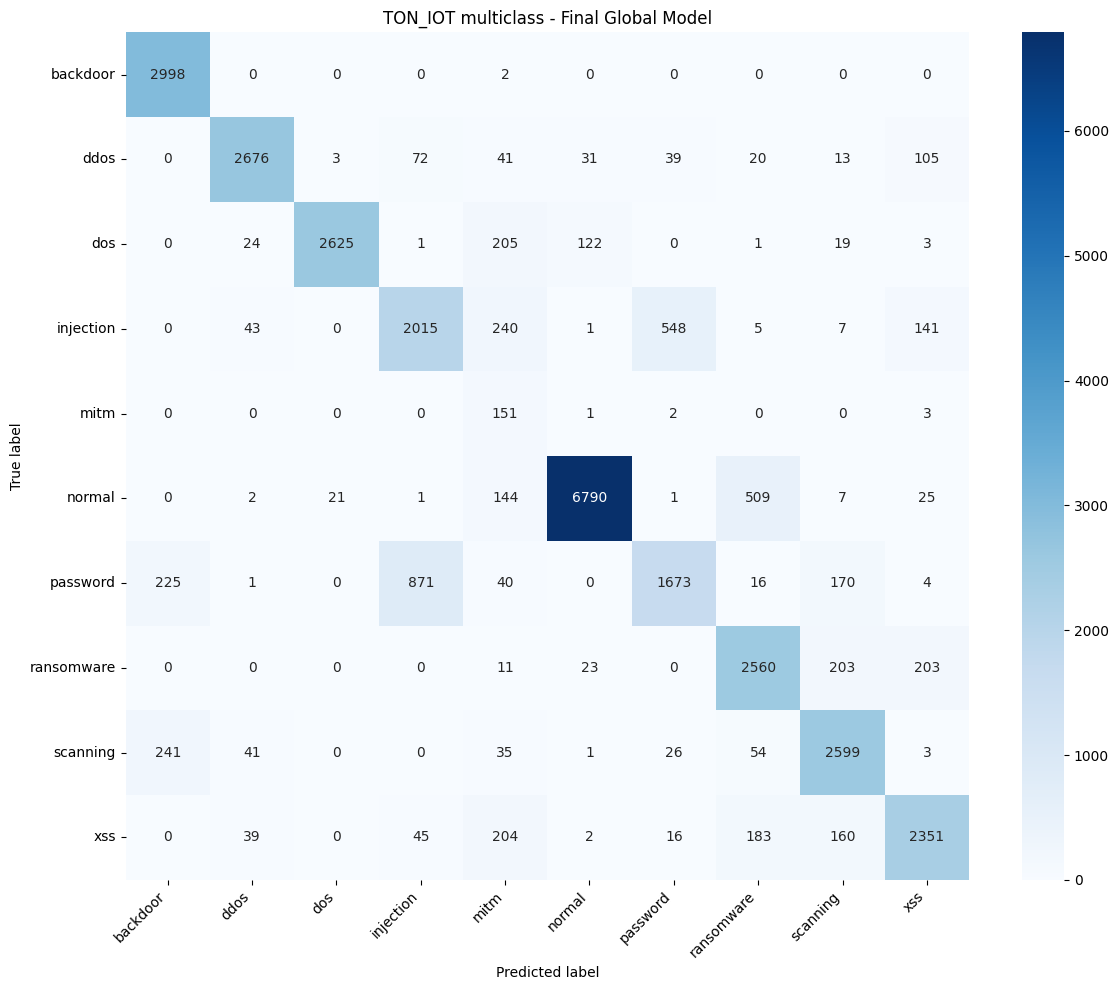

In [18]:
final_metrics, final_predictions = evaluate_model(trained_model, X_test, y_test)
all_labels = np.arange(num_classes)

print("Final metrics:")
print(json.dumps(final_metrics, indent=2))
print()
print(
    classification_report(
        y_test,
        final_predictions,
        labels=all_labels,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0,
    )
)

report = classification_report(
    y_test,
    final_predictions,
    labels=all_labels,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
pd.DataFrame(report).transpose().to_csv(
    OUTPUT_DIR / "final_classification_report.csv"
)

cm = confusion_matrix(y_test, final_predictions, labels=all_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title(f"TON_IOT {TARGET_MODE} - Final Global Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_confusion_matrix.png", dpi=300)
plt.show()

In [19]:
trained_model.save(OUTPUT_DIR / "final_best_global_model.keras")
joblib.dump(
    {
        "preprocessor": preprocessor,
        "label_encoder": label_encoder,
        "drop_columns": drop_columns,
        "target_mode": TARGET_MODE,
        "feature_names": feature_names,
    },
    OUTPUT_DIR / "preprocessing.joblib",
)

experiment_config = {
    "seed": SEED,
    "target_mode": TARGET_MODE,
    "experiment_mode": EXPERIMENT_MODE,
    "num_clients": NUM_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "min_samples_per_class_per_client": MIN_SAMPLES_PER_CLASS_PER_CLIENT,
    "share_pct": SHARE_PCT,
    "share_fraction": SHARE_FRACTION,
    "corrupt_clients": CORRUPT_CLIENTS,
    "corruption_rate": CORRUPTION_RATE,
    "num_rounds": NUM_ROUNDS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "noise_scale": NOISE_SCALE,
    "validation_threshold": VALIDATION_THRESHOLD,
    "samples_per_class": SAMPLES_PER_CLASS,
    "best_round": int(best_round),
    "train_samples": int(len(y_train)),
    "validation_samples": int(len(y_val)),
    "test_samples": int(len(y_test)),
    "input_dim": int(input_dim),
    "classes": label_encoder.classes_.tolist(),
}
(OUTPUT_DIR / "experiment_config.json").write_text(
    json.dumps(experiment_config, indent=2), encoding="utf-8"
)
print("Saved experiment artifacts to:", OUTPUT_DIR.resolve())

Saved experiment artifacts to: F:\odib\Shiyun-R2-revision\revised-code\TON_IOT\ton_iot_multiclass_clean_optimized


## Reporting Protocol

Use the default `EXPERIMENT_MODE = "clean"` run as the TON_IOT generalization result.
Then run the same notebook with `EXPERIMENT_MODE = "robust"` as a separate robustness
experiment. Do not combine these into one headline number.

For a defensible paper result:

1. run at least three seeds and report mean plus standard deviation;
2. compare against standard FedAvg under the identical partition;
3. report accuracy, macro precision, macro recall, macro F1, and weighted F1;
4. retain the original test distribution and do not tune using test performance.